##  Cross-Country Comparison & Climate Vulnerability Ranking

Importing dependencies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading 

In [2]:
df1 = pd.read_csv("data/ethiopia_clean.csv")
df2 = pd.read_csv("data/kenya_clean.csv")
df3 = pd.read_csv("data/sudan_clean.csv")
df4 = pd.read_csv("data/nigeria_clean.csv")
df5 = pd.read_csv("data/tanzania_clean.csv")

combined_df = pd.concat([df1,df2,df3,df4,df5], ignore_index=True)

print(combined_df.head())

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   

   WS2M_MAX     PS  QV2M   country        Date  Month  
0      5.07  77.13  4.00  Ethiopia  2015-01-01      1  
1      4.19  77.14  3.35  Ethiopia  2015-01-02      1  
2      2.76  77.11  3.43  Ethiopia  2015-01-03      1  
3      1.28  77.07  4.60  Ethiopia  2015-01-04      1  
4      2.14  77.01  5.58  Ethiopia  2015-01-05      1  


In [3]:
print(combined_df.tail())

       YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  \
20535  2026   86  27.63    30.65    25.66       4.99         2.96  77.48   
20536  2026   87  27.51    31.23    24.84       6.39         1.65  77.72   
20537  2026   88  27.74    31.21    25.33       5.88         1.28  77.35   
20538  2026   89  27.83    31.29    25.31       5.98         0.92  76.50   
20539  2026   90  28.14    31.55    26.06       5.49         0.83  74.46   

       WS2M  WS2M_MAX      PS   QV2M   country        Date  Month  
20535  1.57      2.40  100.73  17.72  Tanzania  2026-03-27      3  
20536  1.36      1.79  100.61  17.59  Tanzania  2026-03-28      3  
20537  1.53      2.01  100.42  17.81  Tanzania  2026-03-29      3  
20538  1.64      2.15  100.43  17.72  Tanzania  2026-03-30      3  
20539  1.35      1.90  100.47  17.56  Tanzania  2026-03-31      3  


### 2. Temperature Trend Comparison

**Monthly average T2M for all five countries**

C:\Users\user\AppData\Local\Temp\ipykernel_10312\1177145405.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = combined_df.groupby("country")["T2M"].resample("M").mean().reset_index()


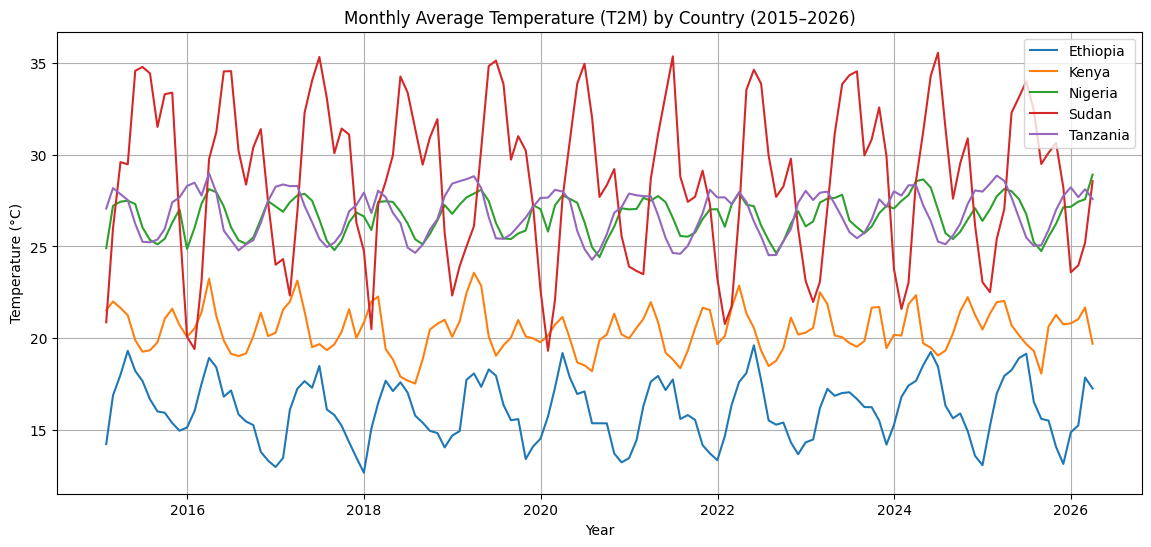

In [4]:
#Convert to datetime
combined_df["Date"] = pd.to_datetime(combined_df["YEAR"] * 1000 + combined_df["DOY"], format="%Y%j")

combined_df = combined_df[(combined_df["Date"].dt.year >= 2015) & (combined_df["Date"].dt.year <= 2026)]


combined_df.set_index("Date", inplace=True)

#Monthly average T2M per country
monthly_temp = combined_df.groupby("country")["T2M"].resample("M").mean().reset_index()

plt.figure(figsize=(14,6))

for country in monthly_temp["country"].unique():
    data = monthly_temp[monthly_temp["country"] == country]
    plt.plot(data["Date"], data["T2M"], label=country)

plt.title("Monthly Average Temperature (T2M) by Country (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()


 **Summary statistics table for Temperature**

In [5]:
summary_table = combined_df.groupby("country")["T2M"].agg(
    mean="mean",
    median="median",
    std="std"
).reset_index()

print(summary_table)

    country       mean  median       std
0  Ethiopia  16.068500   16.04  1.898050
1     Kenya  20.427600   20.36  1.440824
2   Nigeria  26.656928   26.82  1.123335
3     Sudan  28.759007   29.16  4.681305
4  Tanzania  26.802422   26.99  1.325388


### 3.Precipitation Variability Comparison

**Boxplots of PRECTOTCORR for all five countries**

<Figure size 1200x600 with 0 Axes>

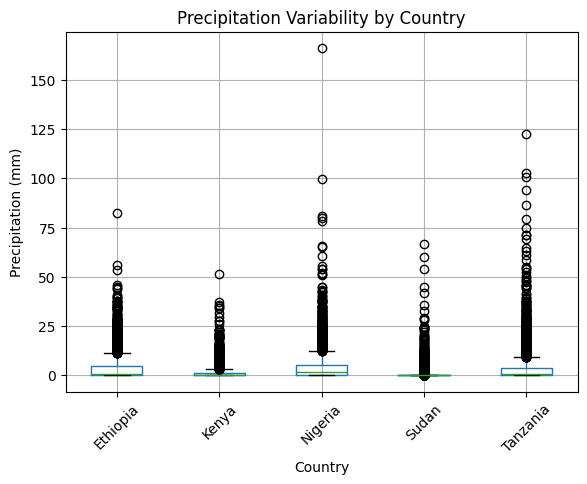

In [6]:
plt.figure(figsize=(12,6))

combined_df.boxplot(column="PRECTOTCORR", by="country")

plt.title("Precipitation Variability by Country")
plt.suptitle("")  
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

 **Summary statistics table for precipitation**

In [7]:
summary_precipitation = combined_df.groupby("country")["PRECTOTCORR"].agg(
    mean="mean",
    median="median",
    std="std"
).reset_index()

print(summary_precipitation)

    country      mean  median       std
0  Ethiopia  3.633795    0.82  6.289061
1     Kenya  1.468162    0.38  3.180228
2   Nigeria  4.213914    1.84  7.266742
3     Sudan  0.643875    0.00  3.057672
4  Tanzania  3.740256    0.64  8.003947


### 4.Extreme Event Frequency

**counting the number of days per year where T2M_MAX exceeds 35°C (extreme heat)**

In [14]:
df = combined_df.copy()

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Year"] = df["Date"].dt.year 

extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = (
    extreme_heat
    .groupby(["country", "Year"])
    .size()
    .reset_index(name="Extreme_Heat_Days")
)

print(heat_counts)

   country  Year  Extreme_Heat_Days
0    Sudan  2015                280
1    Sudan  2016                252
2    Sudan  2017                266
3    Sudan  2018                248
4    Sudan  2019                251
5    Sudan  2020                195
6    Sudan  2021                212
7    Sudan  2022                202
8    Sudan  2023                262
9    Sudan  2024                223
10   Sudan  2025                260
11   Sudan  2026                 43


In [15]:
df.groupby("country")["T2M_MAX"].max()

country
Ethiopia    30.93
Kenya       34.27
Nigeria     32.88
Sudan       45.96
Tanzania    33.93
Name: T2M_MAX, dtype: float64

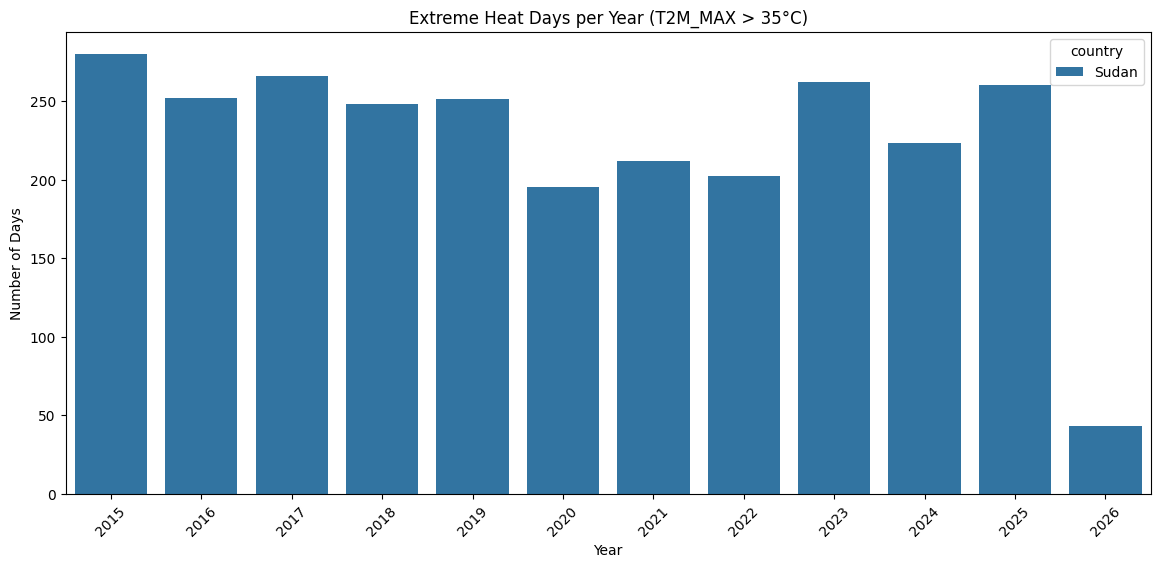

In [19]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=heat_counts,
    x="Year",
    y="Extreme_Heat_Days",
    hue="country"
)

plt.title("Extreme Heat Days per Year (T2M_MAX > 35°C)")
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)

plt.show()

**count the number of consecutive dry days per year (days where PRECTOTCORR < 1 mm)**

In [20]:
df = combined_df.copy().reset_index(drop=True)

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Year"] = df["Date"].dt.year

df = df.dropna(subset=["PRECTOTCORR"])

df = df.sort_values(["country", "Year", "Date"])

df["is_dry"] = df["PRECTOTCORR"] < 1

df["dry_group"] = (df["is_dry"] != df["is_dry"].shift()).cumsum()

dry_streaks = (
    df[df["is_dry"]]
    .groupby(["country", "Year", "dry_group"])
    .size()
    .reset_index(name="streak_length")
)

dry_counts = (
    dry_streaks
    .groupby(["country", "Year"])["streak_length"]
    .max()
    .reset_index(name="Max_Consecutive_Dry_Days")
)

print(dry_counts)


     country  Year  Max_Consecutive_Dry_Days
0   Ethiopia  2015                        25
1   Ethiopia  2016                        35
2   Ethiopia  2017                        43
3   Ethiopia  2018                        35
4   Ethiopia  2019                        46
5   Ethiopia  2020                        39
6   Ethiopia  2021                        28
7   Ethiopia  2022                        29
8   Ethiopia  2023                        55
9   Ethiopia  2024                        38
10  Ethiopia  2025                        61
11  Ethiopia  2026                        21
12     Kenya  2015                        56
13     Kenya  2016                        43
14     Kenya  2017                        38
15     Kenya  2018                        25
16     Kenya  2019                        44
17     Kenya  2020                        22
18     Kenya  2021                        54
19     Kenya  2022                        48
20     Kenya  2023                        45
21     Ken

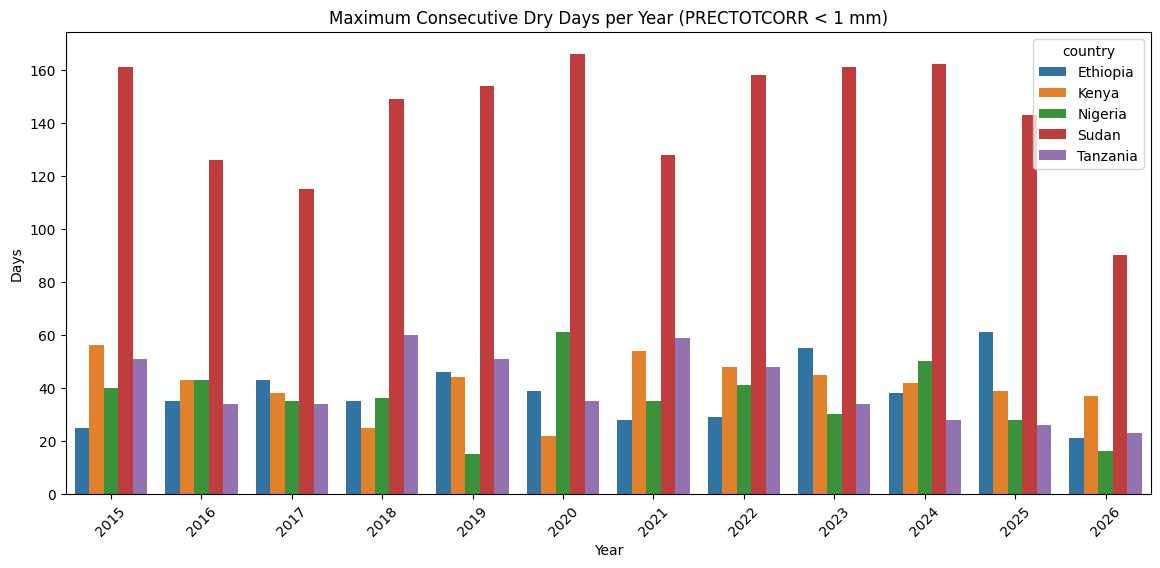

In [21]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=dry_counts,
    x="Year",
    y="Max_Consecutive_Dry_Days",
    hue="country"
)

plt.title("Maximum Consecutive Dry Days per Year (PRECTOTCORR < 1 mm)")
plt.xlabel("Year")
plt.ylabel("Days")
plt.xticks(rotation=45)

plt.show()